# RQ2b results figures -- plan

Builds the figure backing RQ2b's attribution claims in
`documentation/august_draft/5_Chapter_results_evaluation/f_written_draft_v1_18thaug.tex`.
4survey only, by design -- RQ2b has no 6survey arm anywhere in this project.

**Figure in this notebook**

| Figure | Status | Question it answers |
|---|---|---|
| R2b-1 | **Must-have** | Which variables are large AND stable across model families, and does adding more environmental data close the leftover spatial gap? |
| R2b-4 (new) | Added 2026-08-20 | What does a plot's own trajectory actually look like when it persistently sits above/below the shared curve? |
| R2b-5 (new) | Added 2026-08-20 | Does EN/XGBoost systematically over- or under-predict a plot's departure from the shared curve? |

**Not built here (cut for time)**: R2b-2 (CanopyCover-dropped ablation) and R2b-3 (VIF diagnostic)
were both considered and dropped -- both add nothing beyond what is already precisely stated in
prose (e.g. EN R2 0.350->0.231 on CanopyCover removal), so building either would spend real time
on a confirmation-only appendix figure. If you want them later, the numbers already live in
`TEMP_results/TEMP_rq2_attribution_results_2026-08-11.tex`.

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`. Panel A's whiskers
are fold-to-fold **sample SD** (5 folds), not a CI. Panel B (Moran's I) has no CI computed
anywhere in this project -- shown as a point value with p annotated as text. Panel C shows one
pooled value per compartment (across the 5 test folds), no per-compartment CI.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks (e.g.
# notebooks/model_results/baseline_results.ipynb): walk upward until a folder containing both
# README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from models.common.geo import load_compartment_boundaries, load_plot_coordinates
from models.growth_curve_attribution.residual_spatial_autocorrelation_check import compute_residual_morans_i
from notebooks.results_figures_style import COLOR_EN, COLOR_XGBOOST, COLOR_NEUTRAL_EDGE, DIVERGING_CMAP, apply_rcparams

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 5
COHORT = "4survey"  # RQ2b has no 6survey arm
SET_RUN_NAMES = {
    "Set1": "rq2_attribution_nested_set1_baseline",
    "Set2": "rq2_attribution_nested_set2_top10",
    "Set3": "rq2_attribution_nested_set3_gated_terrain_wind_vif",
    "Set4": "rq2_attribution_nested_set4_gated_all_vif",
}

## Figure R2b-1 -- what global attribution finds, and what it still can not explain

**Research question**: RQ2b items 1-3 -- CanopyCover/thinning dominate across three converging
methods; `slope_degrees` is stable across NLME/EN while `topex` is stable only within NLME; does
the residual's own spatial clustering (Moran's I) shrink as more environmental data is added?

**Data**: Panel A -- Set4 `elastic_net_coefficients.csv` and `nlme_fixed_effects.json`, all 5
folds, `outputs/spatial_block_kfold/rq2_attribution_nested_set4_gated_all_vif/4survey/fold_{0-4}/`.
Panel B -- pooled 5-fold `predictions.csv` (`elastic_net_predicted`, `xgboost_predicted` columns)
for all four sets, joined to plot coordinates, residual Moran's I computed live via the project's
own `compute_residual_morans_i()` -- same function/weights used for every other Moran's I check in
this project. Panel C -- Set4's own pooled EN residual, aggregated to compartment mean, mapped via
`load_compartment_boundaries()`.

**Encoding**: 3-panel composite. Panel A: coefficient forest plot, one row per Set4 variable,
NLME and EN as two side-by-side points per row (not overlaid). Panel B: Moran's I by set, one line
per method (EN, XGBoost). Panel C: diverging compartment-mean residual map, centred at 0.

**Caption must state**: Panel C shows leftover unexplained error, not a spatially-varying
relationship -- unlike RQ3's GNNWR, none of RQ2b's methods (NLME, EN, XGBoost) produce a
coefficient that varies by location.

In [3]:
# --- Panel A data: Set4 EN + NLME coefficients, mean +/- SD across 5 folds ---
set4_dir = project_root / "outputs" / "spatial_block_kfold" / SET_RUN_NAMES["Set4"] / COHORT

en_fold_frames = []
nlme_fold_frames = []
for fold in range(N_FOLDS):
    fold_dir = set4_dir / f"fold_{fold}"
    en_coef = pd.read_csv(fold_dir / "elastic_net_coefficients.csv", index_col=0)
    en_coef.columns = ["coefficient"]
    en_coef["fold"] = fold
    en_fold_frames.append(en_coef.reset_index(names="variable"))

    with open(fold_dir / "nlme_fixed_effects.json") as f:
        nlme_json = json.load(f)["fixed_effects"]
    nlme_fold = pd.DataFrame(
        [{"variable": var, "coefficient": vals["coefficient"], "fold": fold} for var, vals in nlme_json.items()]
    )
    nlme_fold_frames.append(nlme_fold)

en_all_folds = pd.concat(en_fold_frames, ignore_index=True)
nlme_all_folds = pd.concat(nlme_fold_frames, ignore_index=True)

en_summary = en_all_folds.groupby("variable")["coefficient"].agg(["mean", "std"]).rename(
    columns={"mean": "en_mean", "std": "en_sd"})
nlme_summary = nlme_all_folds.groupby("variable")["coefficient"].agg(["mean", "std"]).rename(
    columns={"mean": "nlme_mean", "std": "nlme_sd"})
panel_a_data = en_summary.join(nlme_summary, how="outer").fillna(0)
panel_a_data = panel_a_data.reindex(panel_a_data["en_mean"].abs().sort_values(ascending=True).index)
print(panel_a_data.tail(10))

                              en_mean     en_sd  nlme_mean   nlme_sd
variable                                                            
eastness                     0.471401  0.086700   0.326031  0.019374
gwa_weibull_a_50m           -0.578801  0.609239   0.342354  0.065753
whcl                        -0.593820  0.228107  -0.459338  0.400075
chelsa_bio12_precip_mm      -0.620317  0.505404  -1.417072  0.618038
recent_thinning_5yr         -0.975385  0.273215  -0.403295  0.286372
slope_degrees                0.992606  0.217116   0.860705  0.237592
dist_to_road                -1.331564  0.170686  -1.216036  0.129702
CanopyCover                  1.943018  0.038438   1.863654  0.078258
time_since_thinning         -2.139253  0.216411  -1.474595  0.596377
time_since_thinning_missing -2.994821  0.182380  -1.320848  0.698048


In [4]:
# --- Panel B + C data: pooled predictions per set, residual, Moran's I, and Set4's own map ---
coordinates = load_plot_coordinates()

panel_b_rows = []
set4_pooled_with_xy = None
for set_label, run_name in SET_RUN_NAMES.items():
    frames = []
    for fold in range(N_FOLDS):
        p = project_root / "outputs" / "spatial_block_kfold" / run_name / COHORT / f"fold_{fold}" / "predictions.csv"
        frames.append(pd.read_csv(p))
    pooled = pd.concat(frames, ignore_index=True)
    pooled = pooled[pooled["split"] == "test"] if "split" in pooled.columns else pooled
    pooled = pooled.merge(coordinates, on="identification", how="left")
    pooled["en_residual"] = pooled["observed"] - pooled["elastic_net_predicted"]
    pooled["xgb_residual"] = pooled["observed"] - pooled["xgboost_predicted"]

    # compute_residual_morans_i returns 5 values (semivariogram-informed distance-band
    # convention) -- range_m differs per residual field, so it is kept alongside each row rather
    # than assumed to match across methods/sets.
    en_i, en_p, en_n, en_range_m, en_status = compute_residual_morans_i(pooled["x"], pooled["y"], pooled["en_residual"])
    xgb_i, xgb_p, xgb_n, xgb_range_m, xgb_status = compute_residual_morans_i(pooled["x"], pooled["y"], pooled["xgb_residual"])
    panel_b_rows.append({"set": set_label, "method": "Elastic Net", "morans_i": en_i, "p_value": en_p, "range_m": en_range_m})
    panel_b_rows.append({"set": set_label, "method": "XGBoost", "morans_i": xgb_i, "p_value": xgb_p, "range_m": xgb_range_m})
    print(f"{set_label}: EN Moran's I={en_i:.3f} (p={en_p:.3f}, range={en_range_m:.0f}m), "
          f"XGB Moran's I={xgb_i:.3f} (p={xgb_p:.3f}, range={xgb_range_m:.0f}m)")

    if set_label == "Set4":
        set4_pooled_with_xy = pooled  # reused directly for Panel C, no re-pooling

panel_b_data = pd.DataFrame(panel_b_rows)

  semivariogram range = 1665m (status: resolved)
  semivariogram range = 1675m (status: resolved)
Set1: EN Moran's I=0.145 (p=0.001, range=1665m), XGB Moran's I=0.146 (p=0.001, range=1675m)
  semivariogram range = 1488m (status: resolved)
  semivariogram range = 1385m (status: resolved)
Set2: EN Moran's I=0.105 (p=0.001, range=1488m), XGB Moran's I=0.032 (p=0.001, range=1385m)
  semivariogram range = 1682m (status: resolved)
  semivariogram range = 1459m (status: resolved)
Set3: EN Moran's I=0.110 (p=0.001, range=1682m), XGB Moran's I=0.077 (p=0.001, range=1459m)
  semivariogram range = 1739m (status: resolved)
  semivariogram range = 1671m (status: resolved)
Set4: EN Moran's I=0.103 (p=0.001, range=1739m), XGB Moran's I=0.054 (p=0.001, range=1671m)


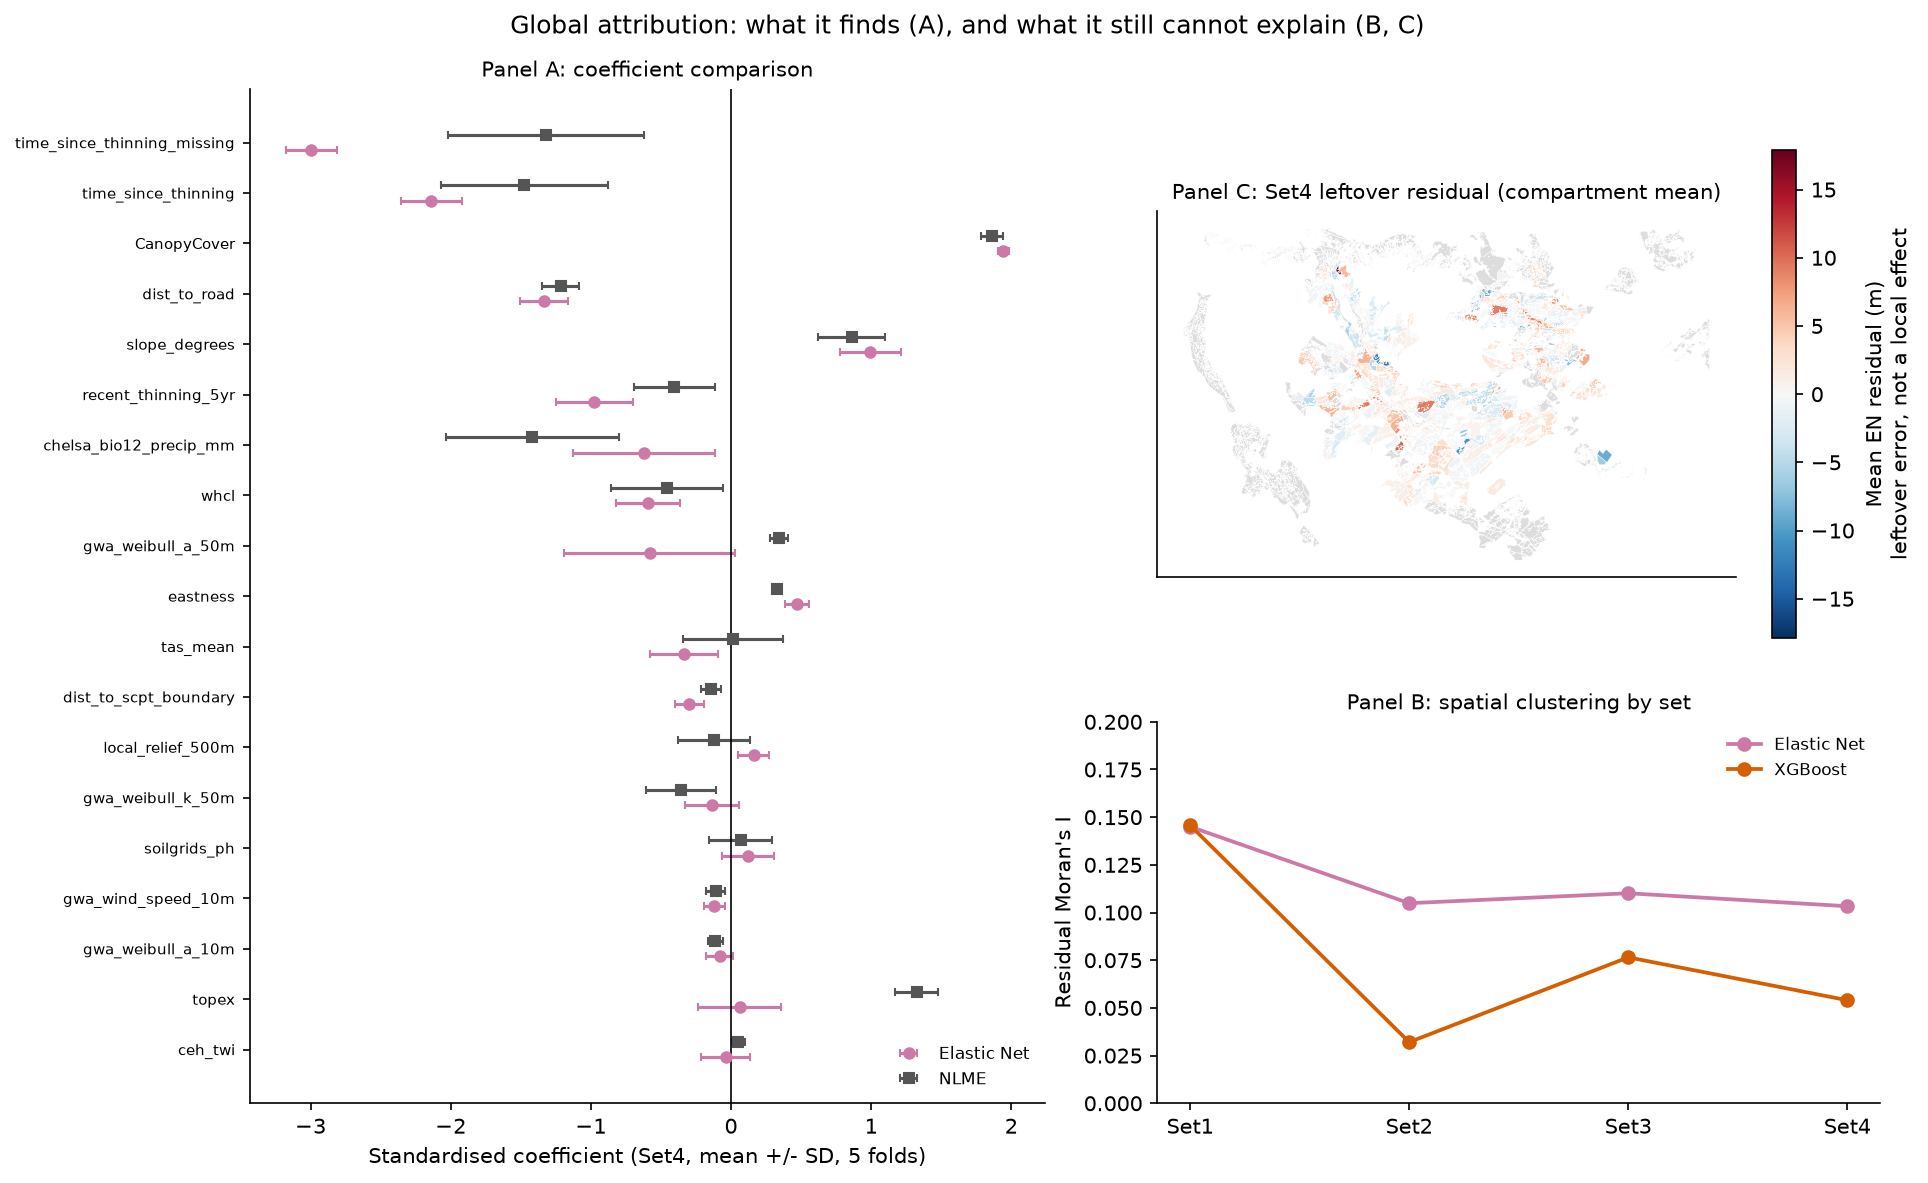

In [5]:
fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1], height_ratios=[1.6, 1])
ax_a = fig.add_subplot(gs[:, 0])
ax_b = fig.add_subplot(gs[1, 1])
ax_c = fig.add_subplot(gs[0, 1])

# --- Panel A: coefficient forest plot ---
y_positions = np.arange(len(panel_a_data))
ax_a.errorbar(panel_a_data["en_mean"], y_positions - 0.15, xerr=panel_a_data["en_sd"],
              fmt="o", color=COLOR_EN, markersize=5, capsize=2, label="Elastic Net")
ax_a.errorbar(panel_a_data["nlme_mean"], y_positions + 0.15, xerr=panel_a_data["nlme_sd"],
              fmt="s", color=COLOR_NEUTRAL_EDGE, markersize=5, capsize=2, label="NLME")
ax_a.axvline(0, color="black", linewidth=0.8)
ax_a.set_yticks(y_positions)
ax_a.set_yticklabels(panel_a_data.index, fontsize=7)
ax_a.set_xlabel("Standardised coefficient (Set4, mean +/- SD, 5 folds)")
ax_a.set_title("Panel A: coefficient comparison", fontsize=10)
ax_a.legend(fontsize=8, frameon=False, loc="lower right")

# --- Panel B: Moran's I by set ---
for method, color in [("Elastic Net", COLOR_EN), ("XGBoost", COLOR_XGBOOST)]:
    subset = panel_b_data[panel_b_data["method"] == method]
    ax_b.plot(subset["set"], subset["morans_i"], marker="o", color=color, label=method, linewidth=1.8)
# Rescaled 2026-08-20: was set_ylim(0, 0.8), calibrated for the old stale k=8 Moran's I range.
# Corrected semivariogram-informed values sit in 0.03-0.15 (see printed cell output above), so the
# old axis would have squashed every point near zero. 0.2 gives real headroom above the highest
# plotted point (~0.146) without exaggerating how much visual "room" the values use.
ax_b.set_ylim(0, 0.2)
ax_b.set_ylabel("Residual Moran's I")
ax_b.set_title("Panel B: spatial clustering by set", fontsize=10)
ax_b.legend(fontsize=8, frameon=False)

# --- Panel C: Set4 EN residual, compartment mean, mapped ---
compartment_mean = set4_pooled_with_xy.groupby("cpmt")["en_residual"].mean().reset_index()
boundaries = load_compartment_boundaries()
mapped = boundaries.merge(compartment_mean, on="cpmt", how="left")
vmax = mapped["en_residual"].abs().max()
norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
mapped.plot(column="en_residual", cmap=DIVERGING_CMAP, norm=norm, ax=ax_c,
            edgecolor="white", linewidth=0.2, missing_kwds={"color": "#DDDDDD"})
sm = plt.cm.ScalarMappable(cmap=DIVERGING_CMAP, norm=norm)
fig.colorbar(sm, ax=ax_c, shrink=0.8, label="Mean EN residual (m)\nleftover error, not a local effect")
ax_c.set_title("Panel C: Set4 leftover residual (compartment mean)", fontsize=10)
ax_c.set_aspect("equal")
ax_c.set_xticks([]); ax_c.set_yticks([])

fig.suptitle("Global attribution: what it finds (A), and what it still cannot explain (B, C)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "q1_attribution_composite.png", dpi=200, bbox_inches="tight")
plt.show()

## Figure R2b-4 (new) -- example plots by residual tier

**Research question**: RQ2b asks "what explains a plot's persistent departure from the shared
curve" -- every existing RQ2b figure answers this only in aggregate (coefficients, R2, Moran's I).
This is the first figure that shows what "departure from the shared curve" actually looks like for
a real plot's own observed trajectory.

**Data**: `models.xgb_environmental.data.load_plots_for_cohort("4survey")` for the real per-plot
`mean_cr_residual` target (71,766 plots, already verified against the known population count) --
sort by this value, take the 2 most positive (persistently ABOVE the shared curve), 2 most negative
(persistently BELOW), 2 nearest zero (typical/well-fit). Raw per-survey rows via
`load_filtered_growth_curve_table("4survey")`. Benchmark curve: the pooled 4survey Chapman-Richards
fit (y_max=51.963, k=0.010371, p=0.865 -- the same frozen anchor cited throughout this chapter).

**Encoding**: 6 small multiples (2 per tier), each plot's own observed trajectory (solid) against
the single POOLED curve (dashed) -- deliberately the pooled curve, not a yield-class benchmark
(that is RQ3's target, not RQ2b's), so this figure visualizes exactly what `mean_cr_residual` means.

In [6]:
from models.xgb_environmental.data import load_plots_for_cohort
from models.growth_curve_attribution.data import load_filtered_growth_curve_table
from models.chapman_richards.chapman_richards import chapman_richards

CR_PARAMS_4SURVEY = {"y_max": 51.963, "k": 0.010371, "p": 0.865}  # pooled anchor, cited throughout this chapter

plots_with_residual = load_plots_for_cohort("4survey")
above = plots_with_residual.sort_values("mean_cr_residual", ascending=False).head(2)
below = plots_with_residual.sort_values("mean_cr_residual", ascending=True).head(2)
typical = plots_with_residual.iloc[(plots_with_residual["mean_cr_residual"]).abs().argsort()[:2]]

tier_plots = list(above["identification"]) + list(typical["identification"]) + list(below["identification"])
tier_labels = ["above curve", "above curve", "typical", "typical", "below curve", "below curve"]
tier_residuals = list(above["mean_cr_residual"]) + list(typical["mean_cr_residual"]) + list(below["mean_cr_residual"])
print("Selected plots by tier:", list(zip(tier_plots, tier_labels, [round(r, 2) for r in tier_residuals])))

growth_rows_rq2b = load_filtered_growth_curve_table("4survey")

Selected plots by tier: [(369039, 'above curve', 31.34), (89414, 'above curve', 29.4), (160751, 'typical', 0.0), (369807, 'typical', 0.0), (351168, 'below curve', -26.27), (309024, 'below curve', -26.23)]
  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


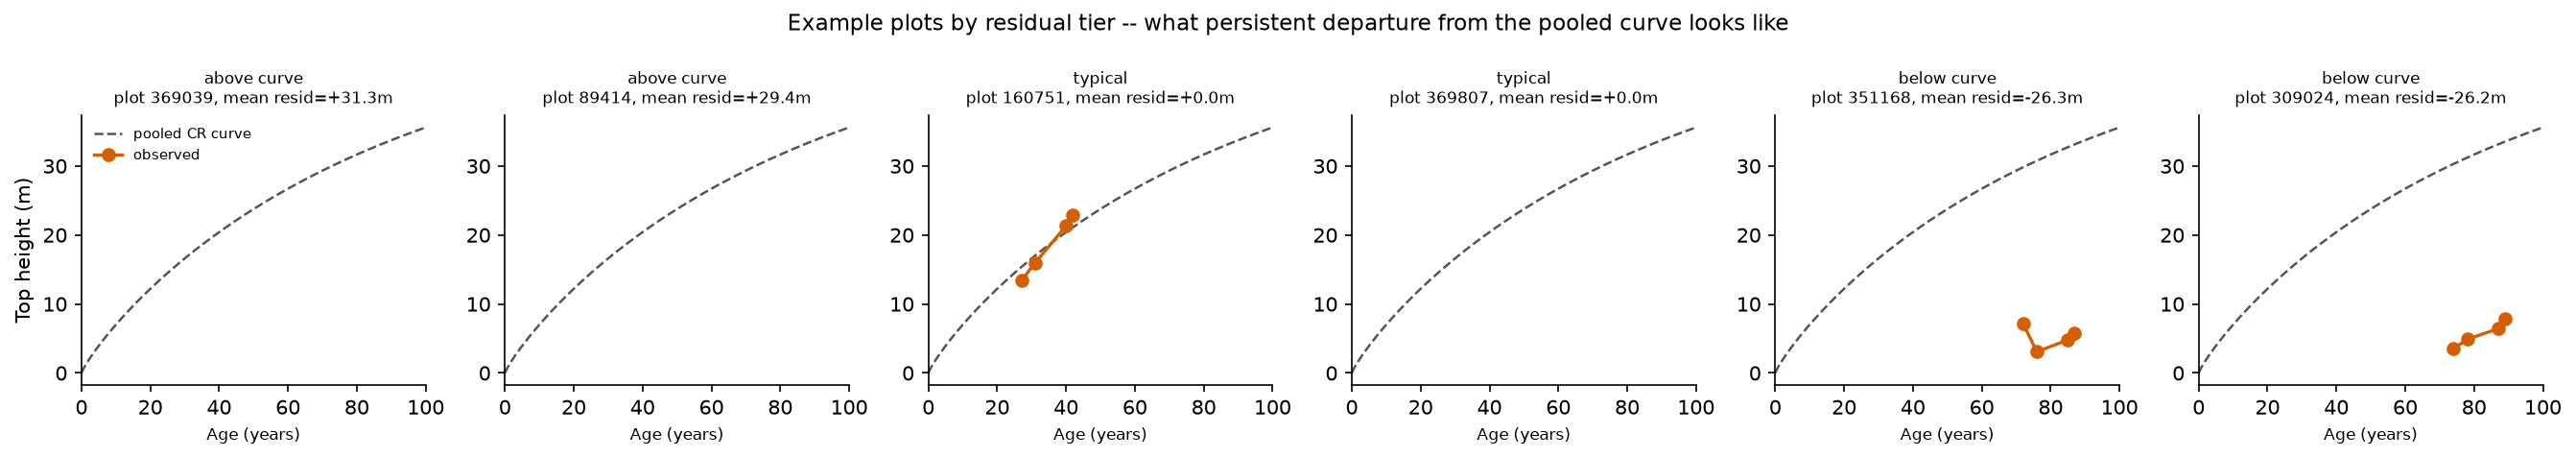

In [7]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2), sharey=False)
age_range = np.linspace(0, 100, 200)
cr_curve = chapman_richards(age_range, CR_PARAMS_4SURVEY["y_max"], CR_PARAMS_4SURVEY["k"], CR_PARAMS_4SURVEY["p"])

for ax, plot_id, label, residual in zip(axes, tier_plots, tier_labels, tier_residuals):
    plot_rows = growth_rows_rq2b[growth_rows_rq2b["identification"] == plot_id].sort_values("Age")
    ax.plot(age_range, cr_curve, linestyle="--", color=COLOR_NEUTRAL_EDGE, linewidth=1.2, label="pooled CR curve")
    ax.plot(plot_rows["Age"], plot_rows["elev_percentile_95th"], marker="o", color=COLOR_XGBOOST,
            linewidth=1.6, label="observed")
    ax.set_title(f"{label}\nplot {int(plot_id)}, mean resid={residual:+.1f}m", fontsize=8)
    ax.set_xlabel("Age (years)", fontsize=8)
    ax.set_xlim(0, 100)

axes[0].set_ylabel("Top height (m)")
axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Example plots by residual tier -- what persistent departure from the pooled curve looks like", fontsize=11)
plt.tight_layout()
plt.show()

## Figure R2b-5 (new) -- does the model over- or under-predict?

**Research question**: complements RQ2b's coefficient-direction story with an actual bias check --
none of the existing RQ2b figures show whether EN/XGBoost systematically over- or under-predict
`mean_cr_residual`, only which variables matter and by how much.

**Data**: reuses the same pooled Set4 predictions already loaded for Figure R2b-1's Panel B/C
(`set4_pooled_with_xy`, columns `observed`, `elastic_net_predicted`, `xgboost_predicted`) -- no new
data, no new fitting.

**Encoding**: predicted vs. observed scatter, one panel per method, 1:1 reference line (perfect
prediction). Points above the line = under-prediction (model predicts less departure than real);
below = over-prediction.

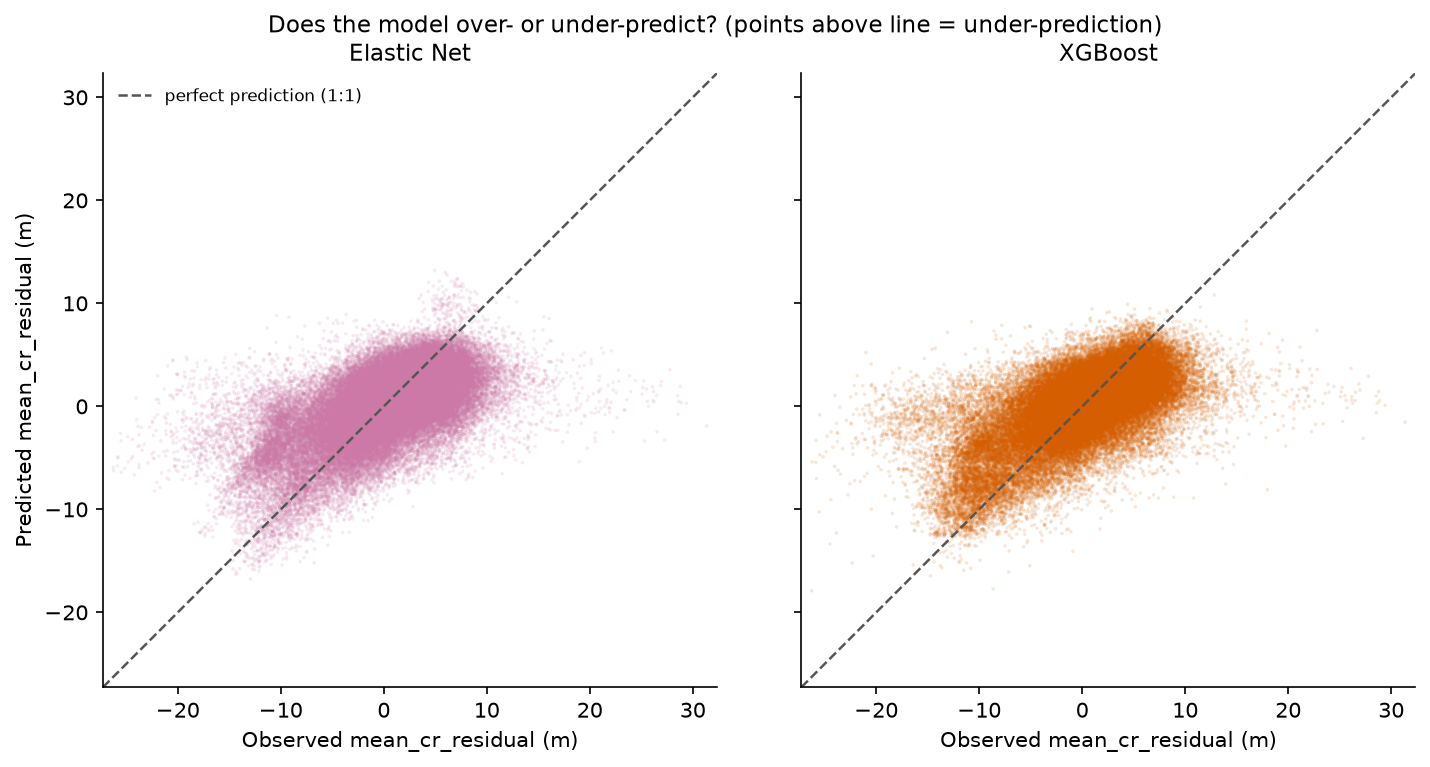

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
axis_limits = (set4_pooled_with_xy["observed"].min() - 1, set4_pooled_with_xy["observed"].max() + 1)

for ax, pred_col, label, color in [
    (axes[0], "elastic_net_predicted", "Elastic Net", COLOR_EN),
    (axes[1], "xgboost_predicted", "XGBoost", COLOR_XGBOOST),
]:
    ax.scatter(set4_pooled_with_xy["observed"], set4_pooled_with_xy[pred_col],
               s=3, alpha=0.15, color=color, edgecolor="none")
    ax.plot(axis_limits, axis_limits, color=COLOR_NEUTRAL_EDGE, linewidth=1.2, linestyle="--",
            label="perfect prediction (1:1)")
    ax.set_xlim(axis_limits); ax.set_ylim(axis_limits)
    ax.set_aspect("equal")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Observed mean_cr_residual (m)")

axes[0].set_ylabel("Predicted mean_cr_residual (m)")
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("Does the model over- or under-predict? (points above line = under-prediction)", fontsize=11)
plt.tight_layout()
plt.show()